# Keras Experiments on the Diabetes Data

The experiment ladder from the regression side (`U1_RealEstate-4_Keras`), replayed on real clinical data: start with a bare network on raw features, then add one change per scenario - feature scaling, a bolder learning rate and more depth, Dropout, BatchNormalization - and let the metrics judge each rung.

On the real-estate data the ladder climbed dramatically. **Does it climb here too?** Readmission prediction is a much harder, noisier problem - treat every scenario as a hypothesis, not a foregone conclusion.

One setup note: we draw a **balanced** subsample (equal positives and negatives) so that architecture effects are readable in plain accuracy. Handling the dataset's true ~11% imbalance is the very next topic (`U1-7_Imbalance-*`, `U1_Diabetes-6_Imbalance`).

## Learning objectives

- Run a controlled ladder of experiments, changing exactly one thing per rung
- Judge a classifier on a rare-event problem by F1 and AUC rather than accuracy
- Apply feature scaling, learning-rate and depth changes, Dropout, and BatchNormalization
- Read a flat ladder honestly: recognize when a problem's ceiling has already been reached

## Background

This notebook assumes the preprocessed readmission table from `U1_Diabetes-2_Preprocess`, the Keras
`Sequential` API from `U1-6_Classify-5_KerasIntro`, and the metrics from
`U1_Diabetes-3_Classification` — F1 on the minority class and ROC AUC. Each architectural idea
(Dropout, BatchNormalization) is explained at the rung that introduces it.

The design principle is the important part: **one change per scenario**. If two things change at
once and the score moves, nothing has been learned about either.

**Prerequisites:** `U1-6_Classify-5_KerasIntro` (Keras classification),
`U1_Diabetes-3_Classification` (the metrics and the class imbalance),
`U1_RealEstate-4_Keras` (the same ladder on the regression side)

**Dataset:** `diabetes_hospital_preprocessed.csv` — the encoded output of
`U1_Diabetes-2_Preprocess`.

**References:** https://keras.io/api/layers/regularization_layers/dropout/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Data

Preprocessed by `U1_Diabetes-2_Preprocess`. We deliberately do **not** scale the features yet -
that is Scenario 2's job.

The deliberate omission is scaling, and it is there so Scenario 2 has something to demonstrate. The
utilization counts run from 0 into the hundreds while the dummy columns are 0/1, so the first
network has to cope with input scales differing by two orders of magnitude — a handicap gradient
descent feels directly, since a weight update sized for one feature is wrong for the other.

Everything else is held fixed across all five scenarios: same split, same seed, same target, same
metrics. Only the one factor named in each scenario changes.


In [2]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Seeds so the scenario comparison is reproducible run-to-run
np.random.seed(42)
tf.random.set_seed(42)

data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'
df = pd.read_csv(data_folder + 'Diabetes/diabetes_hospital_preprocessed.csv')

# Balanced subsample: 5,000 per class
n_samp_per_class = 5000
df_pos = df[df['readmit_30_days'] == 1].sample(n_samp_per_class, random_state=42)
df_neg = df[df['readmit_30_days'] == 0].sample(n_samp_per_class, random_state=42)
df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

y = df['readmit_30_days']
X = df.drop(columns=['readmit_30_days'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)

scenario_results = {}

(8000, 41) (2000, 41)


## 2. Scenario 1: Baseline — raw features

A small network straight on the unscaled features. The utilization counts range 0-100+ while
the dummy columns are 0/1 - gradient descent has to fight that imbalance in input scales.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216 (864.00 B)

 Trainable params: 216 (864.00 B)

 Non-trainable params: 0 (0.00 B)

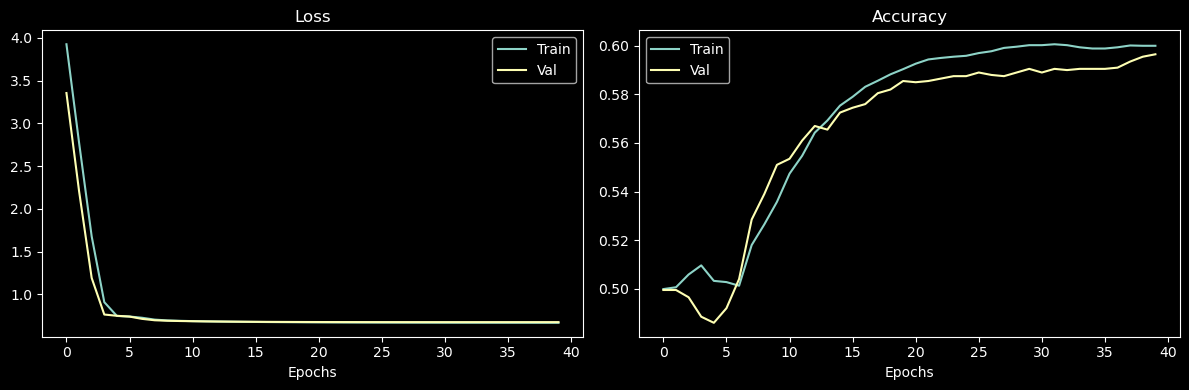

                 precision    recall  f1-score   support

 Not readmitted       0.59      0.61      0.60      1000
Readmitted <30d       0.60      0.59      0.59      1000

       accuracy                           0.60      2000
      macro avg       0.60      0.60      0.60      2000
   weighted avg       0.60      0.60      0.60      2000



In [3]:
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

X_tr, X_te = X_train.values.astype(float), X_test.values.astype(float)

model = Sequential([
    Input(shape=X_tr.shape[1:]),
    Dense(5, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_tr, y_train,
    epochs=40, batch_size=256, shuffle=True,
    validation_data=(X_te, y_test), verbose=0
)

# --- evaluate ---
y_test_prob = model.predict(X_te, verbose=0)[:,0]
y_test_pred = (y_test_prob > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epochs'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epochs'); axes[1].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_test_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

scenario_results['S1 baseline (raw)'] = {
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'Test F1': f1_score(y_test, y_test_pred),
    'Test AUC': roc_auc_score(y_test, y_test_prob),
}

## 3. Scenario 2: Feature scaling

Same architecture, but the features go through `StandardScaler` (fit on the training set
only). Classification labels need no scaling - the features are the whole story here.

This is the rung that should matter most, and for a mechanical reason. Gradient descent takes one
learning rate for every weight, but the gradient with respect to a weight is proportional to the
size of its input. With inputs spanning two orders of magnitude, the step that is right for the
dummy columns is far too small for the count columns, or the step right for the counts is far too
large for the dummies. No single learning rate serves both.

Standardizing removes the conflict. Note the scaler is fit on the **training** split and merely
applied to the test split — fitting on both would leak test statistics into training, the rule
established in `U1-2_Preprocess`.


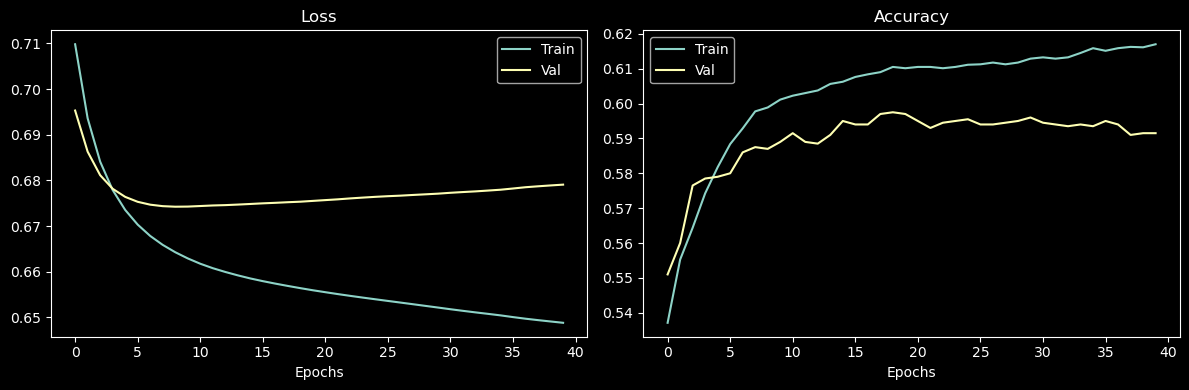

                 precision    recall  f1-score   support

 Not readmitted       0.60      0.55      0.57      1000
Readmitted <30d       0.58      0.64      0.61      1000

       accuracy                           0.59      2000
      macro avg       0.59      0.59      0.59      2000
   weighted avg       0.59      0.59      0.59      2000



In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

model = Sequential([
    Input(shape=X_tr.shape[1:]),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_tr, y_train,
    epochs=40, batch_size=256, shuffle=True,
    validation_data=(X_te, y_test), verbose=0
)

# --- evaluate ---
y_test_prob = model.predict(X_te, verbose=0)[:,0]
y_test_pred = (y_test_prob > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epochs'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epochs'); axes[1].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_test_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

scenario_results['S2 + scale X'] = {
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'Test F1': f1_score(y_test, y_test_pred),
    'Test AUC': roc_auc_score(y_test, y_test_prob),
}

## 4. Scenario 3: Learning rate and depth

With clean inputs, we can afford a deeper network and a bolder learning rate. Adam's default is
`0.001`; we raise it to `0.01` and stack three hidden layers.

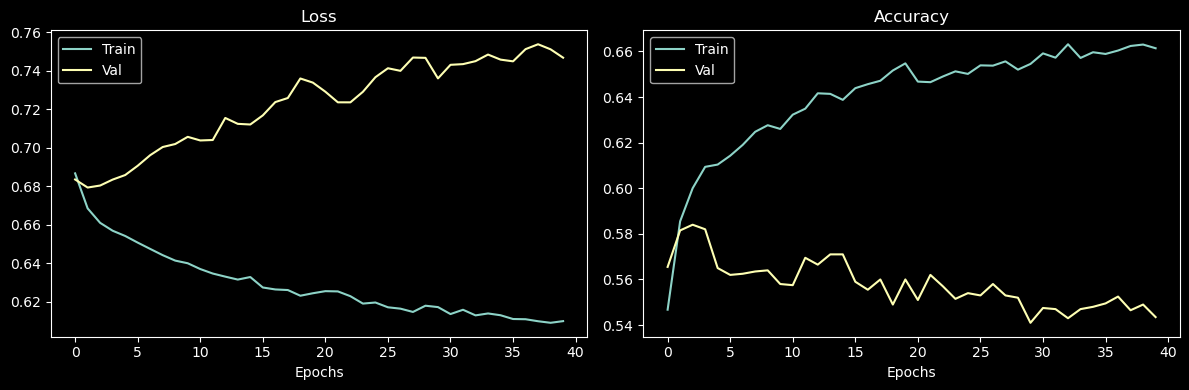

                 precision    recall  f1-score   support

 Not readmitted       0.54      0.54      0.54      1000
Readmitted <30d       0.54      0.55      0.55      1000

       accuracy                           0.54      2000
      macro avg       0.54      0.54      0.54      2000
   weighted avg       0.54      0.54      0.54      2000



In [5]:
model = Sequential([
    Input(shape=X_tr.shape[1:]),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_tr, y_train,
    epochs=40, batch_size=256, shuffle=True,
    validation_data=(X_te, y_test), verbose=0
)

# --- evaluate ---
y_test_prob = model.predict(X_te, verbose=0)[:,0]
y_test_pred = (y_test_prob > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epochs'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epochs'); axes[1].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_test_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

scenario_results['S3 + LR & depth'] = {
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'Test F1': f1_score(y_test, y_test_pred),
    'Test AUC': roc_auc_score(y_test, y_test_prob),
}

## 5. Scenario 4: Including dropout

Wider layers give the network more capacity; **Dropout** keeps that capacity from being spent
on memorizing training patients. Watch the train/validation gap in the curves - that is what
Dropout is managing.

**Dropout** randomly zeroes a fraction of a layer's activations on each training step — 30% here.
The network cannot rely on any particular unit being present, so it is pushed to spread the
representation across units rather than concentrate it in a few detectors that memorize specific
training patients.

The mechanism only runs during training; at prediction time every unit is active and outputs are
scaled to compensate. That asymmetry is why the training loss can look *worse* than the validation
loss in a Dropout model — the training number is measured on a deliberately handicapped network.
Watch the train/validation gap rather than either curve alone.


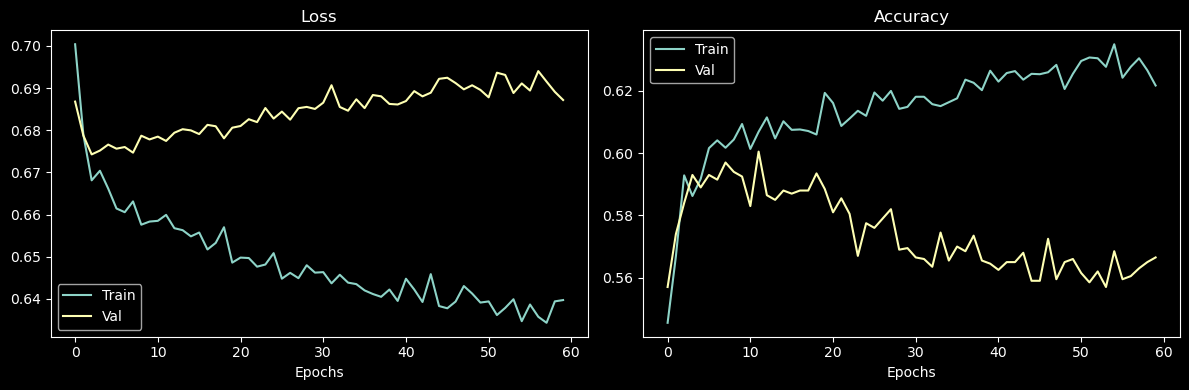

                 precision    recall  f1-score   support

 Not readmitted       0.55      0.68      0.61      1000
Readmitted <30d       0.59      0.46      0.51      1000

       accuracy                           0.57      2000
      macro avg       0.57      0.57      0.56      2000
   weighted avg       0.57      0.57      0.56      2000



In [6]:
model = Sequential([
    Input(shape=X_tr.shape[1:]),
    Dense(20, activation='relu'),
    Dropout(0.3),
    Dense(20, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_tr, y_train,
    epochs=60, batch_size=256, shuffle=True,
    validation_data=(X_te, y_test), verbose=0
)

# --- evaluate ---
y_test_prob = model.predict(X_te, verbose=0)[:,0]
y_test_pred = (y_test_prob > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epochs'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epochs'); axes[1].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_test_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

scenario_results['S4 + Dropout'] = {
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'Test F1': f1_score(y_test, y_test_pred),
    'Test AUC': roc_auc_score(y_test, y_test_prob),
}

## 6. Scenario 5: Add batch normalization

**BatchNormalization** re-standardizes activations between layers, stabilizing training and
tolerating higher learning rates. Placed after the linear transformation, before the
activation, with lighter dropout (`0.1`).

**BatchNormalization** standardizes each layer's pre-activation outputs across the current batch, so
every layer receives inputs with a stable distribution regardless of how the layers beneath it have
shifted during training. It is the Scenario 2 idea — put inputs on a sane scale — applied *between*
layers rather than only at the entrance.

Placement matters and is deliberate here: after the linear transform, before the activation. Dropout
is also lowered to 0.1, because BatchNorm supplies some regularization of its own through the noise
in per-batch statistics, and stacking both at full strength tends to underfit.


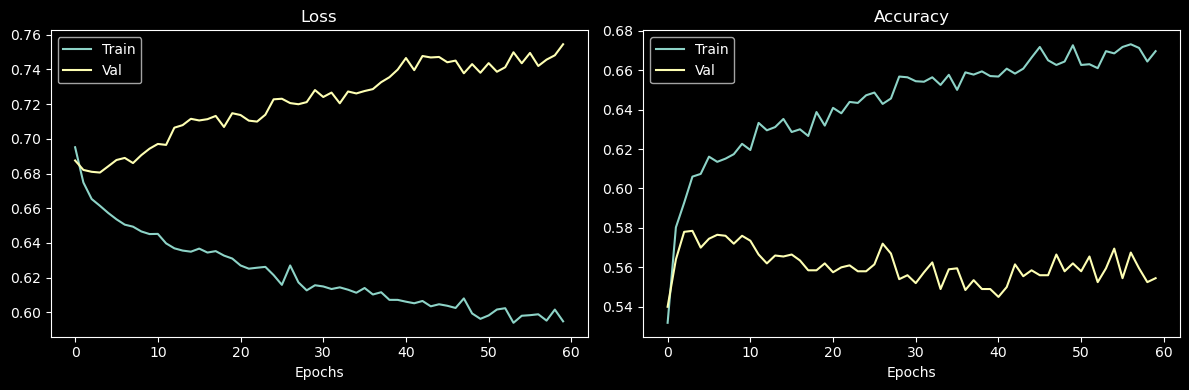

                 precision    recall  f1-score   support

 Not readmitted       0.55      0.60      0.57      1000
Readmitted <30d       0.56      0.51      0.53      1000

       accuracy                           0.55      2000
      macro avg       0.55      0.55      0.55      2000
   weighted avg       0.55      0.55      0.55      2000



In [7]:
model = Sequential([
    Input(shape=X_tr.shape[1:]),

    Dense(20),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1),

    Dense(20),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.1),

    Dense(20, activation='relu'),

    Dense(1, activation='sigmoid'),
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_tr, y_train,
    epochs=60, batch_size=256, shuffle=True,
    validation_data=(X_te, y_test), verbose=0
)

# --- evaluate ---
y_test_prob = model.predict(X_te, verbose=0)[:,0]
y_test_pred = (y_test_prob > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epochs'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epochs'); axes[1].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_test_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

scenario_results['S5 + BatchNorm'] = {
    'Test Accuracy': accuracy_score(y_test, y_test_pred),
    'Test F1': f1_score(y_test, y_test_pred),
    'Test AUC': roc_auc_score(y_test, y_test_prob),
}

## 7. Comparison

Read the table by *differences between adjacent rows*, since each row differs from the one above it
by exactly one change. That is what makes a ladder interpretable — a jump between two rows is
attributable to the single thing that changed, which is not true of a table of models that differ in
several ways at once.

Read the bar chart with the same caution applied to every comparison in this unit: these are
single-split numbers. A difference smaller than the fold-to-fold spread seen in
`U1_Diabetes-4_Keras` is not evidence of anything.


,Test Accuracy,Test F1,Test AUC
S1 baseline (raw),0.5965,0.5926,0.6174
S2 + scale X,0.5915,0.6089,0.6129
S3 + LR & depth,0.5435,0.5464,0.5606
S4 + Dropout,0.5665,0.5121,0.5999
S5 + BatchNorm,0.5545,0.5333,0.5731


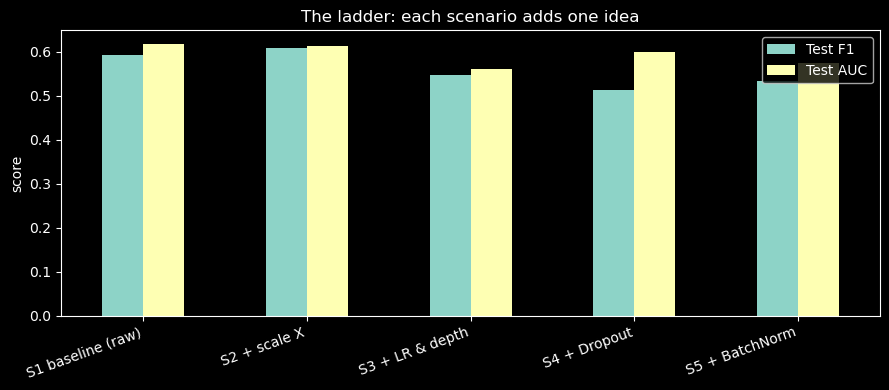

In [8]:
comparison = pd.DataFrame(scenario_results).T
display(comparison.round(4))

comparison[['Test F1', 'Test AUC']].plot(kind='bar', figsize=(9, 4))
plt.ylabel('score')
plt.title('The ladder: each scenario adds one idea')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 8. Review — what the ladder actually says here

An honest result: on this problem the ladder is **flat**. The tiny baseline network is already at the data's ceiling (~0.60-0.62 AUC), scaling barely moves it, and the fancier rungs (more depth, BatchNorm) mostly add variance. Compare that with the regression ladder in `U1_RealEstate-4_Keras`, where the same sequence of changes took cross-validated $R^2$ from 0.64 to 0.84.

That contrast *is* the lesson: **architecture is rarely the bottleneck on tabular problems.** When a small model on good features matches a big regularized one, the leverage is in the data - better features, more of it, or (next section) handling the class imbalance you actually care about.